# TAHAP 2 — Kalibrasi Laju Konversi Dasar (Subsistem Lahan)

**Parameter:** Laju Konversi Dasar (satu-satunya; tidak ada parameter berpasangan).
**File:** `Uji_Parsial_P1___P4_V2.mdl`, dengan parameter Tahap 1 dikunci pada nilai turunan
(TPK Ambang 0,275; Laju Demolisi 0,05; Sensitivitas Konstruksi 2,31385).

**Target:** Lahan Terbangun.
**Periode fungsi tujuan:** 2016–2019 dan 2022–2025 (hanya COVID dikeluarkan; lahan terbangun tidak kembali setelah pandemi).
**Fungsi tujuan:** J = NRMSE Lahan.
**Rentang:** CI 95% LOGEST dari Tahap 0 → 0,0034118 sampai 0,0851069; nilai turunan 0,0436052.
**Metode:** grid 1D, 101 titik.

Aturan keputusan R1–R4 dengan himpunan indiferen I = {k : J(k) ≤ 1,05 · J_min}; ambang 2% dan 10% sebagai uji kepekaan.

In [1]:
!pip install pysd openpyxl matplotlib scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 14.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, pysd
from scipy import stats
warnings.filterwarnings("ignore")

FOLDER = Path("/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi")
FILE = FOLDER / "Uji Parsial P1 & P4 V2.mdl"

TAHUN = np.arange(2016, 2026)
OBJ = np.array([2016,2017,2018,2019,2022,2023,2024,2025])
MSK, NONCOVID = np.isin(TAHUN, OBJ), ~np.isin(TAHUN, [2020,2021])
TANPA2025 = MSK & (TAHUN != 2025)

DATA = np.array([44561.0784555117,50223.957001398,56624.3602289948,63480.0442236269,58962.0411105434,
                 59887.5260314565,57709.075808398,75624.403529316,73511.574651116,55029.5352961885])

KHAT, KL, KU = 0.0436052, 0.0034118, 0.0851069          # dari sheet Tahap 0
PARAM_TAHAP1 = {"TPK Ambang":0.275, "Laju Demolisi Dasar":0.05,
                "Sensitivitas Konstruksi terhadap TPK":2.31385}

In [4]:
def nrmse(sim, act, msk):
    return np.sqrt(np.mean((sim[msk]-act[msk])**2)) / act[msk].mean()

def statistik(sim, act, t):
    e = sim-act; SA, SS, SE = act.std(), sim.std(), e.std()
    r = np.corrcoef(sim, act)[0,1]; mse = np.mean(e**2)
    la, ls = stats.linregress(t, act), stats.linregress(t, sim); n = len(t)
    th = abs(ls.slope-la.slope)/np.sqrt(la.stderr**2+ls.stderr**2); tt = stats.t.ppf(0.975, 2*n-4)
    tren = ("Berlawanan arah" if np.sign(ls.slope) != np.sign(la.slope)
            else ("Berbeda nyata" if th > tt else "Tidak berbeda nyata"))
    return {"Tren":tren, "E1":abs(sim.mean()-act.mean())/abs(act.mean()), "E2":abs(SS-SA)/SA,
            "DC":SE/(SA+SS), "U1":(sim.mean()-act.mean())**2/mse, "U2":(SS-SA)**2/mse,
            "U3":2*(1-r)*SS*SA/mse, "MAPE (%)":100*np.mean(np.abs(e/act))}

model = pysd.read_vensim(str(FILE))

def run(k):
    p = dict(PARAM_TAHAP1); p["Laju Konversi Dasar"] = k
    r = model.run(params=p, return_columns=["Lahan Terbangun"], return_timestamps=list(TAHUN))
    return np.real(r["Lahan Terbangun"].values.astype(complex))

h0 = run(KHAT)
print(f"Cek titik turunan: Lahan 2025 = {h0[-1]:,.2f} (harus 61.783,84) | J = {nrmse(h0,DATA,MSK):.5f} (harus 0,17264)")

Cek titik turunan: Lahan 2025 = 61,783.84 (harus 61.783,84) | J = 0.17264 (harus 0,17264)


## Grid 101 titik

In [5]:
K = np.linspace(KL, KU, 101)
cache, baris = {}, []
for k in K:
    h = run(k); cache[k] = h
    baris.append({"Laju Konversi Dasar":k, "J (NRMSE Lahan, objektif)":nrmse(h,DATA,MSK),
                  "NRMSE (tanpa COVID)":nrmse(h,DATA,NONCOVID),
                  "NRMSE (objektif tanpa 2025)":nrmse(h,DATA,TANPA2025), "Lahan 2025":h[-1]})
grid = pd.DataFrame(baris)
jmin = grid["J (NRMSE Lahan, objektif)"].min()
kopt = grid.loc[grid["J (NRMSE Lahan, objektif)"].idxmin(), "Laju Konversi Dasar"]
jt = nrmse(h0, DATA, MSK)
print(f"Optimum k = {kopt:.7f} | J = {jmin:.5f} | J turunan = {jt:.5f} | perbaikan {100*(jt-jmin)/jt:.2f}%")

Optimum k = 0.0638662 | J = 0.14716 | J turunan = 0.17264 | perbaikan 14.76%


## Aturan keputusan

In [6]:
hasil = []
for amb in [0.02, 0.05, 0.10]:
    I = grid[grid["J (NRMSE Lahan, objektif)"] <= (1+amb)*jmin]
    di_I = jt <= (1+amb)*jmin
    sentuh = (I["Laju Konversi Dasar"].min() <= K[0]+1e-9) and (I["Laju Konversi Dasar"].max() >= K[-1]-1e-9)
    di_batas = abs(kopt-K[0]) < 1e-9 or abs(kopt-K[-1]) < 1e-9
    aturan = ("R1 - pertahankan nilai turunan" if di_I else
              "R2 - tidak teridentifikasi, pertahankan" if sentuh else
              "R3 - optimum di batas, prosedur diagnostik" if di_batas else "R4 - adopsi optimum")
    hasil.append({"Ambang indiferen":f"{amb:.0%}", "J minimum":jmin, "J nilai turunan":jt,
                  "Perbaikan relatif (%)":100*(jt-jmin)/jt, "k optimum":kopt, "Titik dalam I":len(I),
                  "Batas bawah I":I["Laju Konversi Dasar"].min(), "Batas atas I":I["Laju Konversi Dasar"].max(),
                  "Turunan dalam I":bool(di_I), "I menyentuh kedua ujung":bool(sentuh), "Keputusan":aturan})
keputusan = pd.DataFrame(hasil)
keputusan.round(6)

,Ambang indiferen,J minimum,J nilai turunan,Perbaikan relatif (%),k optimum,Titik dalam I,Batas bawah I,Batas atas I,Turunan dalam I,I menyentuh kedua ujung,Keputusan
0,2%,0.147163,0.172642,14.758086,0.063866,16,0.057331,0.069585,False,False,R4 - adopsi optimum
1,5%,0.147163,0.172642,14.758086,0.063866,24,0.054063,0.072853,False,False,R4 - adopsi optimum
2,10%,0.147163,0.172642,14.758086,0.063866,35,0.049161,0.076937,False,False,R4 - adopsi optimum


## Kekokohan dan diagnostik leave-one-year-out

Varian tanpa 2025 dilaporkan karena penurunan Dynamic World 2025 sudah tercatat sebagai anomali.

In [7]:
k_tanpa2025 = grid.loc[grid["NRMSE (objektif tanpa 2025)"].idxmin(), "Laju Konversi Dasar"]
print(f"Optimum bila 2025 dikeluarkan: k = {k_tanpa2025:.7f}\n")

loyo = []
for buang in [None] + list(OBJ):
    th = [t for t in OBJ if t != buang]; msk = np.isin(TAHUN, th)
    best = min(((nrmse(h, DATA, msk), k) for k, h in cache.items()))
    loyo.append({"Tahun dikeluarkan":"(tidak ada)" if buang is None else buang,
                 "k optimum":best[1], "J min":best[0], "J turunan":nrmse(h0, DATA, msk)})
loyo = pd.DataFrame(loyo)
display(loyo.round(6))

print("Residual pada nilai turunan:")
for t, s, d in zip(TAHUN, h0, DATA):
    print(f"  {t}: sim {s:10,.0f}  data {d:10,.0f}  selisih {s-d:+9,.0f} ({100*(s-d)/d:+5.1f}%)")

Optimum bila 2025 dikeluarkan: k = 0.0826560



,Tahun dikeluarkan,k optimum,J min,J turunan
0,(tidak ada),0.063866,0.147163,0.172642
1,2016,0.063866,0.151851,0.178141
2,2017,0.063049,0.152569,0.178810
3,2018,0.063049,0.149702,0.174991
4,2019,0.061415,0.141203,0.164440
5,2022,0.065500,0.154991,0.183218
6,2023,0.055697,0.140481,0.150406
7,2024,0.058148,0.156062,0.167882
8,2025,0.082656,0.092780,0.177578


Residual pada nilai turunan:
  2016: sim     44,561  data     44,561  selisih        +0 ( +0.0%)
  2017: sim     46,243  data     50,224  selisih    -3,981 ( -7.9%)
  2018: sim     47,983  data     56,624  selisih    -8,641 (-15.3%)
  2019: sim     49,803  data     63,480  selisih   -13,677 (-21.5%)
  2020: sim     51,695  data     58,962  selisih    -7,267 (-12.3%)
  2021: sim     53,587  data     59,888  selisih    -6,301 (-10.5%)
  2022: sim     55,536  data     57,709  selisih    -2,174 ( -3.8%)
  2023: sim     57,546  data     75,624  selisih   -18,078 (-23.9%)
  2024: sim     59,651  data     73,512  selisih   -13,861 (-18.9%)
  2025: sim     61,784  data     55,030  selisih    +6,754 (+12.3%)


## Perbandingan statistik dan grafik

,Kondisi,Versi,Tren,E1,E2,DC,U1,U2,U3,MAPE (%),NRMSE
0,"Nilai turunan (0,0436052)",Periode objektif,Tidak berbeda nyata,0.1125,0.3918,0.4813,0.4250,0.1473,0.4277,12.9414,0.1726
1,"Nilai turunan (0,0436052)",Tanpa COVID,Tidak berbeda nyata,0.1125,0.3918,0.4813,0.4250,0.1473,0.4277,12.9414,0.1726
2,"Nilai turunan (0,0436052)",Dengan COVID,Tidak berbeda nyata,0.1129,0.3901,0.4809,0.4811,0.1317,0.3872,12.6378,0.1627
3,Optimum grid (0.063866),Periode objektif,Tidak berbeda nyata,0.0404,0.0657,0.4325,0.0755,0.0057,0.9188,11.7986,0.1472
4,Optimum grid (0.063866),Tanpa COVID,Tidak berbeda nyata,0.0404,0.0657,0.4325,0.0755,0.0057,0.9188,11.7986,0.1472
5,Optimum grid (0.063866),Dengan COVID,Tidak berbeda nyata,0.0418,0.0628,0.4326,0.0979,0.0051,0.8971,10.3862,0.1336


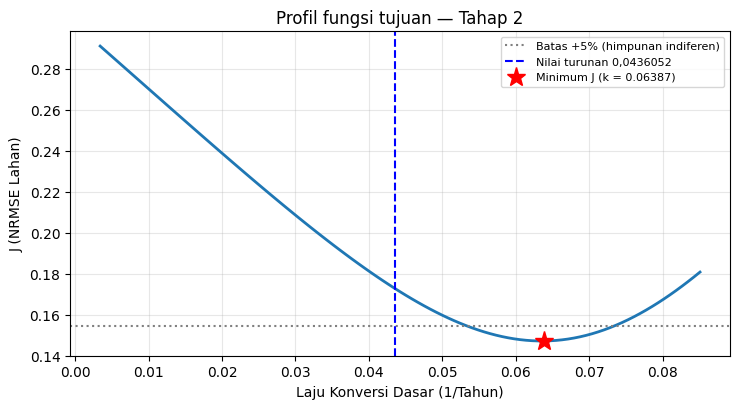

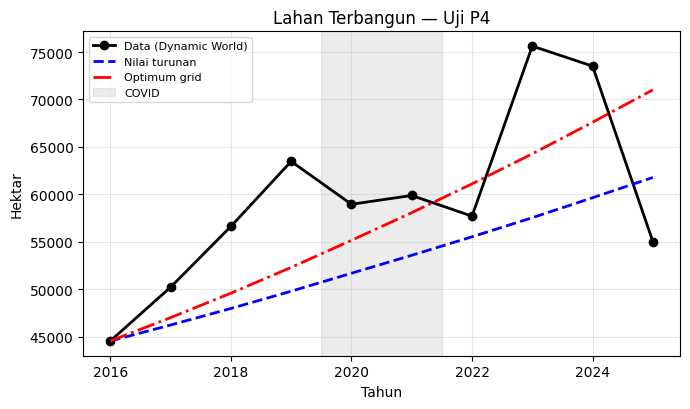

In [8]:
rows = []
for lab, k in [("Nilai turunan (0,0436052)", KHAT), (f"Optimum grid ({kopt:.6f})", kopt)]:
    h = run(k)
    for versi, msk in [("Periode objektif", MSK), ("Tanpa COVID", NONCOVID), ("Dengan COVID", np.ones(10, bool))]:
        rows.append({"Kondisi":lab, "Versi":versi, **statistik(h[msk], DATA[msk], TAHUN[msk]),
                     "NRMSE":nrmse(h, DATA, msk)})
banding = pd.DataFrame(rows)
display(banding.round(4))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(grid["Laju Konversi Dasar"], grid["J (NRMSE Lahan, objektif)"], lw=2)
ax.axhline(1.05*jmin, color="grey", ls=":", label="Batas +5% (himpunan indiferen)")
ax.axvline(KHAT, color="blue", ls="--", label="Nilai turunan 0,0436052")
ax.plot(kopt, jmin, "r*", ms=14, label=f"Minimum J (k = {kopt:.5f})")
ax.set_xlabel("Laju Konversi Dasar (1/Tahun)"); ax.set_ylabel("J (NRMSE Lahan)")
ax.set_title("Profil fungsi tujuan — Tahap 2"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FOLDER / "tahap2_profil_J.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(TAHUN, DATA, "ko-", lw=2, label="Data (Dynamic World)")
ax.plot(TAHUN, h0, "b--", lw=2, label="Nilai turunan")
ax.plot(TAHUN, run(kopt), "r-.", lw=2, label="Optimum grid")
ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.15, label="COVID")
ax.set_xlabel("Tahun"); ax.set_ylabel("Hektar"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("Lahan Terbangun — Uji P4")
fig.tight_layout(); fig.savefig(FOLDER / "tahap2_lahan.png", dpi=150); plt.show()

## Simpan Excel

In [9]:
berkas = FOLDER / "hasil_kalibrasi_tahap2.xlsx"
with pd.ExcelWriter(berkas) as w:
    keputusan.round(6).to_excel(w, sheet_name="Keputusan", index=False)
    banding.round(6).to_excel(w, sheet_name="Perbandingan Statistik", index=False)
    grid.round(6).to_excel(w, sheet_name="Grid", index=False)
    loyo.round(6).to_excel(w, sheet_name="Diagnostik LOYO", index=False)
    pd.DataFrame({"Tahun":TAHUN, "Data":DATA, "Nilai turunan":h0,
                  "Optimum":run(kopt)}).round(3).to_excel(w, sheet_name="Seri Lahan", index=False)
print("Tersimpan:", berkas)

Tersimpan: /content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi/hasil_kalibrasi_tahap2.xlsx


## Angka untuk pencocokan

- Titik turunan: Lahan 2025 = 61.783,84; **J = 0,17264**.
- Optimum: **k = 0,0638662**; J = 0,14716; perbaikan **14,76%**; keputusan **R4 (adopsi)** pada ambang 2%, 5%, dan 10%.
- Himpunan indiferen 5%: k dari 0,054063 sampai 0,072853 (24 titik), tidak menyentuh ujung rentang.
- Statistik pada optimum (periode objektif): E1 0,0404; E2 0,0657; DC 0,4325; U3 0,9188.
- Kekokohan: bila 2025 dikeluarkan, optimum bergeser ke k = 0,0826560.